In [1]:
import glob 
import os
import numpy as np

In [2]:
root_dir="/media/ns/Seagate/oct18"

In [3]:
files=glob.glob(root_dir+"/*")
for file in files:
    if "toupload" in file:
        files.remove(file)
print(files)

['/media/ns/Seagate/oct18/skylar', '/media/ns/Seagate/oct18/ashleigh', '/media/ns/Seagate/oct18/ashley', '/media/ns/Seagate/oct18/lauren']


In [4]:
segments_files=[]

file=files[0]
for file in files:
    segments_all=glob.glob(file+"/**/segments.txt",recursive=True) 
    for segment in segments_all:
        if "cam1" in segment and not "pill" in segment:
            segments_files.append(segment)

len(segments_files)

9

In [5]:
for file in segments_files:
    print(file)
    with open(file,"r") as f:
        segments=f.readlines() 
        print(segments[0]) 

/media/ns/Seagate/oct18/skylar/cam1/rosbag2_skylar_18_1/rosbag2_skylar_18_1/segments.txt
0, 39, not eating

/media/ns/Seagate/oct18/skylar/cam1/rosbag2_skylar_18/rosbag2_skylar_18/segments.txt
0, 709, not eating

/media/ns/Seagate/oct18/ashleigh/cam1/rosbag2_ashleigh_18/rosbag2_ashleigh_18/segments.txt
0, 123, not eating

/media/ns/Seagate/oct18/ashleigh/cam1/rosbag2_ashleigh_18_1/rosbag2_ashleigh_18_1/segments.txt
0, 27, not eating

/media/ns/Seagate/oct18/ashley/cam1/rosbag2_ashley/rosbag2_ashley/segments.txt
0, 66, eating

/media/ns/Seagate/oct18/ashley/cam1/rosbag2_ashley_1/rosbag2_ashley_1/segments.txt
0,10, not eating

/media/ns/Seagate/oct18/lauren/cam1/rosbag2_lauren/rosbag2_lauren/segments.txt
0,38, not eating

/media/ns/Seagate/oct18/lauren/cam1/rosbag2_lauren_1/rosbag2_lauren_1/segments.txt
1, 10, not eating

/media/ns/Seagate/oct18/lauren/cam1/rosbag2_lauren_2/rosbag2_lauren_2/segments.txt
1,24, not eating



In [6]:
def extract_segs(filename):
    segs=[]

    with open(filename) as f:
        lines=f.readlines()
        
    lines=[line.strip() for line in lines]

    for line in lines:
        line=line.split(",") 
        s,e,t=int(line[0]),int(line[1]), line[2].strip()
        # print(s,e,t)
        segs.append((s,e,t))
    return segs

In [7]:
# filename=segments_files[0]
# print(filename)
# segs=extract_segs(filename)
# segs

In [8]:
dir_segs={}
for filename in segments_files:
    filepath = os.path.dirname(filename)
    segs=extract_segs(filename)
    dir_segs[filepath]=segs

dir_segs.keys()
len(dir_segs)

9

In [9]:
eating_files={}
not_eating_files={}
for filepath in dir_segs.keys():
    segs=dir_segs[filepath]
    for s,e,t in segs:
        d=e-s 
        if d<30:
            continue  #skip segments less than 30 frames
        #if t starts with eat
        if t.startswith("eat"):
            if filepath in eating_files:
                eating_files[filepath].append((s,e,t))
            else:
                eating_files[filepath]=[(s,e,t)]
        elif t.startswith("not"):
            if filepath in not_eating_files:
                not_eating_files[filepath].append((s,e,t))
            else:
                not_eating_files[filepath]=[(s,e,t)]

In [10]:
len(eating_files),len(not_eating_files)

(9, 9)

In [11]:
de=[]
for filepath in eating_files.keys():
    segs=eating_files[filepath] 
    for s,e,t in segs:
        de.append(e-s)
        # if (e-s)<50:
        #     print(filepath, e-s) 
de=sorted(de)

dn=[]
for filepath in not_eating_files.keys():
    segs=not_eating_files[filepath] 
    for s,e,t in segs:
        dn.append(e-s)
        # if (e-s)<50:
        #     print(filepath, e-s)
dn=sorted(dn)

len(de), len(dn), np.median(de), np.median(dn), np.max(de), np.max(dn)

(48, 65, 109.0, 58.0, 447, 709)

In [12]:
def generate_segments_adjusted(start, end, length=30, max_overlap=10):
    step = length - max_overlap
    segments = []
    
    current_start = start
    while current_start + length <= end:
        segments.append((current_start, current_start + length))
        current_start += step
    
    # Adjust the start of the last segment if it falls short of the end
    if segments and segments[-1][1] < end:
        last_segment_start = max(start, end - length)
        segments[-1] = (last_segment_start, last_segment_start + length)
    
    return segments

In [13]:
seq_length=30
overlap=10

eating_segs_fixed={}
for filepath in eating_files.keys():
    segs=eating_files[filepath] 
    for s,e,t in segs: 
        more_segs=generate_segments_adjusted(s, e, seq_length, overlap)  
        if filepath in eating_segs_fixed:
            eating_segs_fixed[filepath].extend(more_segs)
        else:
            eating_segs_fixed[filepath]=more_segs
 
not_eating_segs_fixed={}
for filepath in not_eating_files.keys():
    segs=not_eating_files[filepath] 
    for s,e,t in segs: 
        more_segs=generate_segments_adjusted(s, e, seq_length, overlap)  
        if filepath in not_eating_segs_fixed:
            not_eating_segs_fixed[filepath].extend(more_segs)
        else:
            not_eating_segs_fixed[filepath]=more_segs

len(eating_segs_fixed), len(not_eating_segs_fixed)

(9, 9)

In [131]:
# eating_files['/media/ns/Seagate/oct18/skylar/cam1/rosbag2_skylar_18_1/rosbag2_skylar_18_1']

In [14]:
#count eating_segs_fixed
count=sum( [len(eating_segs_fixed[filepath]) for filepath in eating_segs_fixed.keys()] )
count_ne=sum( [len(not_eating_segs_fixed[filepath]) for filepath in not_eating_segs_fixed.keys()] )
count, count_ne

(252, 211)

In [15]:
def parse_p2s(filepath):
    file_p2s= os.path.join(filepath, "p2s.txt") 
    with open(file_p2s, 'r') as f:
        lines=f.readlines()
        lines=[line.strip().strip(',') for line in lines] #remove \n and last comma

        ses=[]
        for line in lines:
            # print(line)
            se=line.split(',')
            if len(se)<4:
                se=[0]*50
            else:
                se=[int(s) for s in se]
            ses.append(se)

        ses=np.array(ses)
    return ses

In [139]:
ses=parse_p2s(filepath)
ses.shape

(1189, 50)

In [16]:
#create dataset
all_rows_eating=[]
for filepath in eating_segs_fixed.keys():
    ses=parse_p2s(filepath)
    fixed_segs=eating_segs_fixed[filepath]
    rows=np.array([ses[s:e] for s,e in fixed_segs] )
    all_rows_eating.append(rows)

all_rows_eating=np.concatenate(all_rows_eating, axis=0)

all_rows_not_eating=[]
for filepath in not_eating_segs_fixed.keys():
    ses=parse_p2s(filepath)
    fixed_segs=not_eating_segs_fixed[filepath]
    rows=np.array([ses[s:e] for s,e in fixed_segs] )
    all_rows_not_eating.append(rows)
all_rows_not_eating=np.concatenate(all_rows_not_eating, axis=0)

all_rows_eating.shape, all_rows_not_eating.shape

((252, 30, 50), (211, 30, 50))

In [17]:
X=np.concatenate([all_rows_eating, all_rows_not_eating], axis=0)
y=np.concatenate([np.ones(all_rows_eating.shape[0]), np.zeros(all_rows_not_eating.shape[0])], axis=0)
X.shape, y.shape

((463, 30, 50), (463,))

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import glob 
import torch
import torch.nn as nn
import torch.optim as optim 
import time 

In [19]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
device 

device(type='cuda')

In [20]:
X=torch.from_numpy(X).float()
y=torch.from_numpy(y).reshape(-1,1)
X.shape, y.shape

(torch.Size([463, 30, 50]), torch.Size([463, 1]))

In [21]:
ids=np.arange(X.shape[0])
np.random.shuffle(ids)
train_ids=ids[:int(len(ids)*0.8)]
test_ids=ids[int(len(ids)*0.8):]
X_train, y_train=X[train_ids], y[train_ids]
X_test, y_test=X[test_ids], y[test_ids]

X_train.shape, y_train.shape, X_test.shape, y_test.shape

(torch.Size([370, 30, 50]),
 torch.Size([370, 1]),
 torch.Size([93, 30, 50]),
 torch.Size([93, 1]))

In [22]:
class LSTM(nn.Module):
    
    def __init__(self,input_dim,hidden_dim,output_dim,layer_num, seq_len):
        super(LSTM,self).__init__()
        self.hidden_dim = hidden_dim
        self.output_dim = output_dim
        self.lstm = torch.nn.LSTM(input_dim,hidden_dim,layer_num,batch_first=True)
        self.fc = torch.nn.Linear(hidden_dim,output_dim)
        self.bn = nn.BatchNorm1d(seq_len)
        
    def forward(self,inputs):
        x = self.bn(inputs)
        lstm_out,(hn,cn) = self.lstm(x)
        out = self.fc(lstm_out[:,-1,:])
        return out

In [23]:
import random
n_data_size_train = X_train.shape[0]
n_data_size_test = X_test.shape[0]

def randomTrainingExampleBatch(batch_size,flag,num=-1):
    if flag == 'train':
        X = X_train
        y = y_train
        data_size = n_data_size_train
    elif flag == 'test':
        X = X_test
        y = y_test
        data_size = n_data_size_test
    if num == -1:
        ran_num = random.randint(0,data_size-batch_size)
    else:
        ran_num = num
    pose_sequence_tensor = X[ran_num:(ran_num+batch_size)]
    pose_sequence_tensor = pose_sequence_tensor
    category_tensor = y[ran_num:ran_num+batch_size,:]
    return category_tensor.long(),pose_sequence_tensor

In [24]:
n_hidden = 128
n_joints = 25*2
n_categories = 2
n_layer = 3
seq_len = 30
rnn = LSTM(n_joints,n_hidden,n_categories,n_layer, seq_len)
rnn.to(device)

LSTM(
  (lstm): LSTM(50, 128, num_layers=3, batch_first=True)
  (fc): Linear(in_features=128, out_features=2, bias=True)
  (bn): BatchNorm1d(30, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)

In [25]:
criterion = nn.CrossEntropyLoss()
learning_rate = 1e-5
# optimizer = optim.SGD(rnn.parameters(),lr=learning_rate,momentum=0.9)

optimizer = optim.Adam(rnn.parameters(),lr=learning_rate)

In [26]:
n_iters = 20_000
print_every = 1000
plot_every = 1000
batch_size = 4

current_loss = 0
all_losses = []

In [27]:
start = time.time()

for iter in range(n_iters+1, n_iters+n_iters + 1):
   
    category_tensor, input_sequence = randomTrainingExampleBatch(batch_size,'train')
    input_sequence = input_sequence.to(device)
    category_tensor = category_tensor.to(device)
    category_tensor = torch.squeeze(category_tensor)
    
    optimizer.zero_grad()
    
    output = rnn(input_sequence)
    loss = criterion(output, category_tensor)
    loss.backward()
    optimizer.step() 
 
    current_loss += loss.item()

    if iter % print_every == 0:
        print('iter: %d, loss: %.3f' % (iter, loss.item()))
    
    
    # Add current loss avg to list of losses
    if iter % plot_every == 0:
        all_losses.append(current_loss / plot_every)
        current_loss = 0

iter: 21000, loss: 0.717
iter: 22000, loss: 0.680
iter: 23000, loss: 0.734
iter: 24000, loss: 0.650
iter: 25000, loss: 0.545
iter: 26000, loss: 0.703
iter: 27000, loss: 0.648
iter: 28000, loss: 0.464
iter: 29000, loss: 0.908
iter: 30000, loss: 0.550
iter: 31000, loss: 0.496
iter: 32000, loss: 0.788
iter: 33000, loss: 1.471
iter: 34000, loss: 0.358
iter: 35000, loss: 0.545
iter: 36000, loss: 0.573
iter: 37000, loss: 0.424
iter: 38000, loss: 0.290
iter: 39000, loss: 0.437
iter: 40000, loss: 0.522


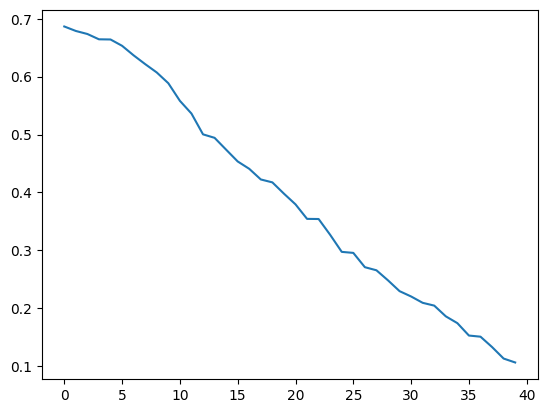

In [172]:
plt.plot(all_losses)

In [28]:
#test 

rnn.eval()

n_correct = 0
n_total = 0
for i in range(n_data_size_test):
    category_tensor, input_sequence = randomTrainingExampleBatch(1,'test',i)
    input_sequence = input_sequence.to(device)
    category_tensor = category_tensor.to(device)
    category_tensor = torch.squeeze(category_tensor)
    output = rnn(input_sequence)
    po=output.argmax(axis=1)
    guess=po.item()
    category = category_tensor
    if category == guess:
        n_correct += 1
    n_total += 1

print('Accuracy of %d test data: %.3f%%' % (n_data_size_test, n_correct / n_total * 100))

Accuracy of 93 test data: 67.742%


In [29]:
#train

rnn.eval()

n_correct = 0
n_total = 0
for i in range(n_data_size_test):
    category_tensor, input_sequence = randomTrainingExampleBatch(1,'train',i)
    input_sequence = input_sequence.to(device)
    category_tensor = category_tensor.to(device)
    category_tensor = torch.squeeze(category_tensor)
    output = rnn(input_sequence)
    po=output.argmax(axis=1)
    guess=po.item()
    category = category_tensor
    if category == guess:
        n_correct += 1
    n_total += 1

print('Accuracy of %d train data: %.3f%%' % (n_data_size_test, n_correct / n_total * 100))

Accuracy of 93 train data: 74.194%
